In [34]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.constants import physical_constants
import matplotlib.pyplot as plt
from uncertainties import ufloat
import _fig_params
colours = _fig_params.colors

Boltzmann = physical_constants['Boltzmann constant in eV/K'][0]

In [22]:
T = np.array([-9.5, 0.5, 10.5, 19.5, 30, 50]) + 273.15
k = np.array([13.4, -1.1, 4.7, 10.8, 50.8, 175.2])
kerr = np.array([20, 20, 20, 20, 20, 20])

In [23]:
def arrhenius(x, ea, k):
    return k * np.exp(-ea / (Boltzmann * x))

In [24]:
popt, pcov = curve_fit(arrhenius, T, k, sigma=kerr, p0=[0.62, 9e11])

In [32]:
names = ['E_a', 'A']
for i in range(len(popt)):
    print("{} = {}".format(names[i], 
                           ufloat(popt[i], np.sqrt(np.diag(pcov)[i]))))

E_a = 0.59+/-0.07
A = (3+/-7)e+11


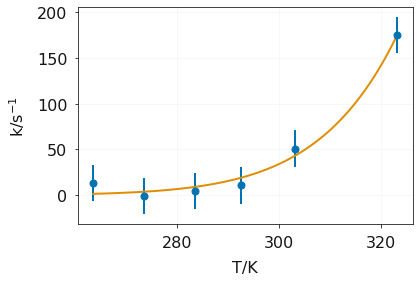

In [36]:
plt.errorbar(T, k, kerr, marker='o', ls='', c=colours[0])
plt.plot(np.linspace(T.min(), T.max(), 100), 
         arrhenius(np.linspace(T.min(), T.max(), 100), *popt), c=colours[1])
plt.ylabel('k/s$^{-1}$')
plt.xlabel('T/K')
plt.show()